![New York City schoolbus](schoolbus.jpg)

Photo by [Jannis Lucas](https://unsplash.com/@jannis_lucas) on [Unsplash](https://unsplash.com).
<br>

Every year, American high school students take SATs, which are standardized tests intended to measure literacy, numeracy, and writing skills. There are three sections - reading, math, and writing, each with a **maximum score of 800 points**. These tests are extremely important for students and colleges, as they play a pivotal role in the admissions process.

Analyzing the performance of schools is important for a variety of stakeholders, including policy and education professionals, researchers, government, and even parents considering which school their children should attend. 

You have been provided with a dataset called `schools.csv`, which is previewed below.

You have been tasked with answering three key questions about New York City (NYC) public school SAT performance.

NYC schools with best math results are:                                            school_name  average_math
88                              Stuyvesant High School           754
170                       Bronx High School of Science           714
93                 Staten Island Technical High School           711
365  Queens High School for the Sciences at York Co...           701
68   High School for Mathematics, Science, and Engi...           683
280                     Brooklyn Technical High School           682
333                        Townsend Harris High School           680
174  High School of American Studies at Lehman College           669
0    New Explorations into Science, Technology and ...           657
45                       Eleanor Roosevelt High School           641


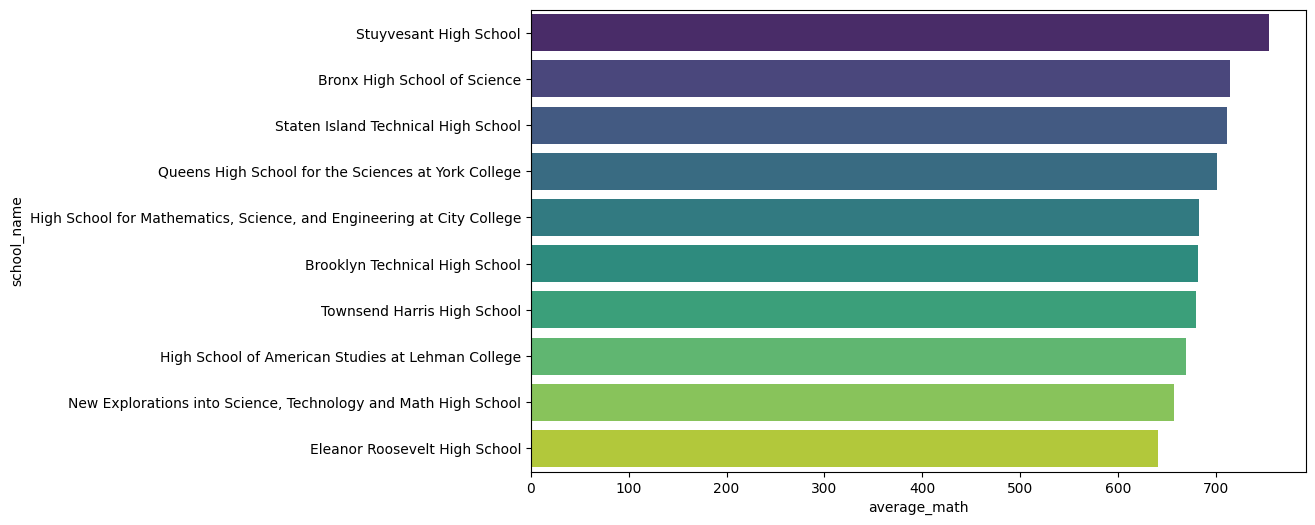

The top 10 performing schools are:                                            school_name  total_SAT
88                              Stuyvesant High School       2144
93                 Staten Island Technical High School       2041
170                       Bronx High School of Science       2041
174  High School of American Studies at Lehman College       2013
333                        Townsend Harris High School       1981
365  Queens High School for the Sciences at York Co...       1947
5                       Bard High School Early College       1914
280                     Brooklyn Technical High School       1896
45                       Eleanor Roosevelt High School       1889
68   High School for Mathematics, Science, and Engi...       1889


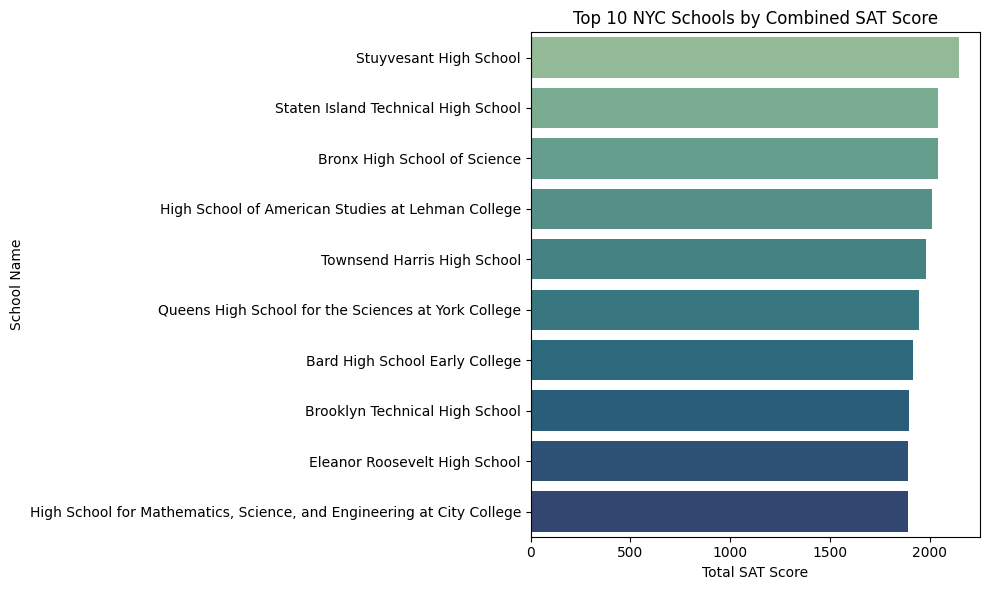

The largest standard deviation in the combined SAT score      borough num_schools  average_SAT  std_SAT
2  Manhattan          89      1340.13   230.29


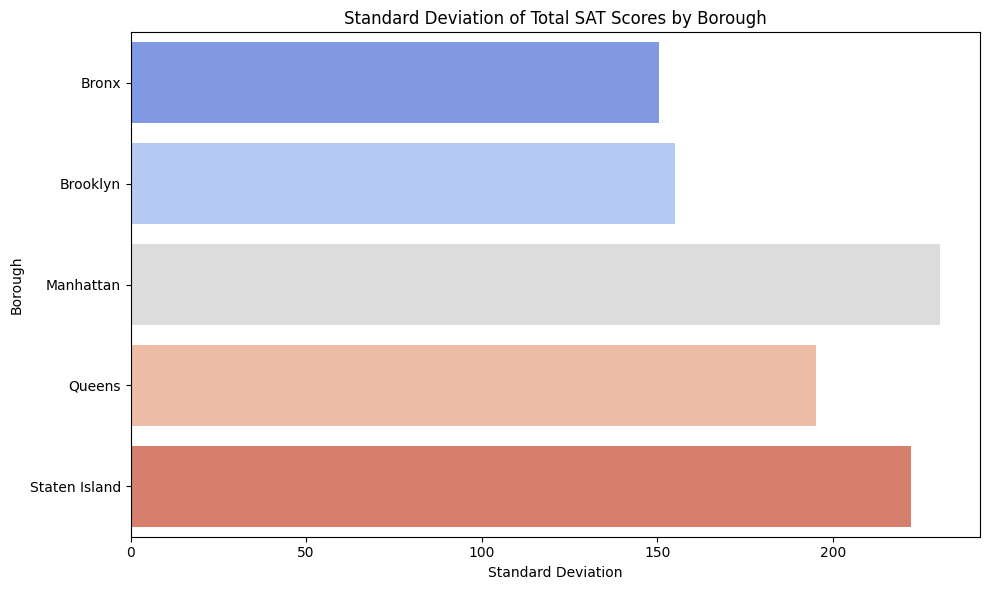

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Read in the data
schools = pd.read_csv("../data/schools.csv")


#1) Which NYC schools have the best math results?
# 80% of 800
best_math_results= 800 * 0.8
best_math_schools= schools[schools["average_math"] >= best_math_results][["school_name", "average_math"]] 

best_math_schools= best_math_schools.sort_values(by= "average_math", ascending= False)
print("NYC schools with best math results are:", best_math_schools)

# Making a grafic of best macth schools data.

plt.figure(figsize=(10, 6))
sns.barplot(data=best_math_schools,x="average_math", y="school_name", hue="school_name", palette="viridis", legend=False)
plt.savefig("../data/best math results.png")
plt.show()

#2)What are the top 10 performing schools based on the combined SAT scores?
schools["total_SAT"] = schools["average_math"].fillna(0) + schools["average_reading"].fillna(0) + schools["average_writing"].fillna(0)# aqui creo la columna y la sumo con los valores nulos en 0.
top_10_schools = schools.nlargest(10, 'total_SAT')[['school_name', 'total_SAT']]# nlargest se usa para contar los 10 valores mas altos de total_SAT y selecciona , lo muestra con nombre y calificacion para mayor claridad
print("The top 10 performing schools are:", top_10_schools)

# Grafic
plt.figure(figsize=(10, 6))
sns.barplot(data=top_10_schools,x="total_SAT",y="school_name",hue="school_name",palette="crest",legend=False)
plt.title("Top 10 NYC Schools by Combined SAT Score")
plt.xlabel("Total SAT Score")
plt.ylabel("School Name")
plt.tight_layout()

# Store grafic
plt.savefig("../data/10 performing schools based on the combined SAT scores.png")
plt.show()

#3) wich single borough has the largest standard deviation in the combined SAT score?
borough_stats= schools.groupby("borough").agg( # .agg permite aplicar múltiples funciones de agregación (como suma, promedio, máximo, mínimo, etc.) de manera simultánea a columnas específicas.
    num_schools= ("school_name", "count"),
    average_SAT= ("total_SAT", "mean"),
    std_SAT= ("total_SAT", "std")
).reset_index()  
largest_std_dev_row = borough_stats.loc[borough_stats["std_SAT"].idxmax()]# idxmax ayuda a identificar en qué fila ocurre el valor máximo de una columna específica.  .loc  se utiliza para acceder a filas y columnas de un DataFrame usando etiquetas de índice o condiciones lógicas.
largest_std_dev= largest_std_dev_row.to_frame().T
# Redondeamos las columnas numéricas a 2 decimales
largest_std_dev["average_SAT"] = largest_std_dev["average_SAT"].astype(float).round(2)
largest_std_dev['std_SAT'] = largest_std_dev['std_SAT'].astype(float).round(2)
print("The largest standard deviation in the combined SAT score", largest_std_dev)

#Grafic
plt.figure(figsize=(10, 6))
sns.barplot(data=borough_stats, x="std_SAT", y="borough", hue="borough", palette="coolwarm")
plt.title("Standard Deviation of Total SAT Scores by Borough")
plt.xlabel("Standard Deviation")
plt.ylabel("Borough")
plt.tight_layout()

# Store Grafic
plt.savefig("../data/largest standard deviation in the combined SAT score.png")
plt.show()



        
